# 🧠 Non-Spatial Multi-Class Fraud Detection Pipeline (3 Advanced Solutions)

In this notebook, we resolve the issue with **Class 2 (Stealth Merchant Fraud)** which was heavily misclassified as Legitimate due to its low-profile individual transaction amounts. 

Because Scenario 2 is injected directly into normal transaction parameters, no standard spatial or transaction-level classifier can decouple them. Instead, we implement and evaluate **three advanced non-spatial solutions**:
1. **Solution 1: Terminal State-Space (Rolling calendar counts)**: Rolling transaction counts over 1-day, 7-day, and 30-day windows to capture volume trajectory spikes at rogue terminals.
2. **Solution 2: Topological Graph Connections**: Tracks terminal-customer connection density, unique customer ratios, and multi-terminal customer card usage.
3. **Solution 3: Sequential Time-Series Deltas**: Tracks the time intervals (deltas) between consecutive transactions at both the terminal level and customer level.

We train a **Multi-Class RandomForest Classifier** on a 10% stratified sample of the 1.75M records to compare these feature groups.

### Cell 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries successfully imported!")

Libraries successfully imported!


### Cell 2: Load the Datasets

In [ ]:
print("Loading datasets from CSV files...")
customer_profiles = pd.read_csv('full dataset with brief/customer_profiles.csv')
fraud_transactions = pd.read_csv('full dataset with brief/synthetic_fraud_transactions.csv')
terminal_profiles = pd.read_csv('full dataset with brief/terminal_profiles.csv')

print(f"Customer Profiles shape: {customer_profiles.shape}")
print(f"Transactions shape: {fraud_transactions.shape}")
print(f"Terminal Profiles shape: {terminal_profiles.shape}")

Loading datasets from CSV files...
Customer Profiles shape: (5000, 7)
Transactions shape: (1754155, 9)
Terminal Profiles shape: (10000, 3)


### Cell 3: Data Merging (Excluding Spatial Coordinates)
We merge transaction records with historical profile statistics, omitting all customer and terminal coordinates (`x_customer_id`, `y_customer_id`, `x_terminal_id`, `y_terminal_id`).

In [ ]:
print("Merging datasets...")

# Merge customer stats (excluding customer coordinates)
df = fraud_transactions.merge(
    customer_profiles[['CUSTOMER_ID', 'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']],
    on='CUSTOMER_ID',
    how='left'
)

# Merge terminal information (excluding terminal coordinates)
df = df.merge(
    terminal_profiles[['TERMINAL_ID']],
    on='TERMINAL_ID',
    how='left'
)

print(f"Columns in merged DataFrame:\n{df.columns.tolist()}")

Merging datasets...
Columns in merged DataFrame:
['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD', 'TX_FRAUD_SCENARIO', 'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']


### Cell 4: Implement 3 Solutions (Advanced Feature Engineering)
We compute rolling counts, customer-terminal connections, and sequential differences on the **entire merged dataset** (1.75M records) so that all sequences remain unbroken, and then sort by datetime.

In [ ]:
print("Engineering features for the 3 solutions...")

# Convert TX_DATETIME to pandas datetime format
df['TX_DATETIME'] = pd.to_datetime(df['TX_DATETIME'])

# Sort by datetime first for correct sequential diffs
df = df.sort_values(by='TX_DATETIME')

# ==========================================================================
# SOLUTION 1: Terminal State-Space (Rolling Counts)
# ==========================================================================
print("Computing Solution 1: Terminal State-Space Rolling Counts...")
all_terminals = df['TERMINAL_ID'].unique()
all_days = np.arange(df['TX_TIME_DAYS'].min(), df['TX_TIME_DAYS'].max() + 1)
idx = pd.MultiIndex.from_product([all_terminals, all_days], names=['TERMINAL_ID', 'TX_TIME_DAYS'])

# Group by terminal and day of simulation, reindex to fill missing days with 0
daily_counts = (df.groupby(['TERMINAL_ID', 'TX_TIME_DAYS'])
                .size()
                .reindex(idx, fill_value=0)
                .reset_index(name='daily_tx_count'))

# Calculate rolling sums over 1-day, 7-day, and 30-day windows
daily_counts['terminal_tx_count_1d'] = daily_counts.groupby('TERMINAL_ID')['daily_tx_count'].transform(lambda x: x.rolling(1, min_periods=1).sum())
daily_counts['terminal_tx_count_7d'] = daily_counts.groupby('TERMINAL_ID')['daily_tx_count'].transform(lambda x: x.rolling(7, min_periods=1).sum())
daily_counts['terminal_tx_count_30d'] = daily_counts.groupby('TERMINAL_ID')['daily_tx_count'].transform(lambda x: x.rolling(30, min_periods=1).sum())

# Merge rolling count features back to main DataFrame
df = df.merge(
    daily_counts[['TERMINAL_ID', 'TX_TIME_DAYS', 'terminal_tx_count_1d', 'terminal_tx_count_7d', 'terminal_tx_count_30d']],
    on=['TERMINAL_ID', 'TX_TIME_DAYS'],
    how='left'
)

# ==========================================================================
# SOLUTION 2: Topological Graph Connections
# ==========================================================================
print("Computing Solution 2: Topological Graph Connection Features...")
# Simple terminal frequency mapping
term_counts = df['TERMINAL_ID'].value_counts()
df['term_count'] = df['TERMINAL_ID'].map(term_counts).fillna(0)

# Unique customers per terminal
df['terminal_unique_cust'] = df.groupby('TERMINAL_ID')['CUSTOMER_ID'].transform('nunique')
# Unique customer-to-transaction ratio (low ratio means repeat cardholders, high ratio means diverse connections)
df['terminal_cust_ratio'] = df['terminal_unique_cust'] / (df['term_count'] + 1e-5)

# Number of unique terminals visited by the customer
df['cust_unique_terminals'] = df.groupby('CUSTOMER_ID')['TERMINAL_ID'].transform('nunique')

# ==========================================================================
# SOLUTION 3: Sequential Time-Series Deltas
# ==========================================================================
print("Computing Solution 3: Sequential Time-Series Deltas...")
# Time delta since last transaction at this terminal (in seconds)
df['term_time_delta'] = df.groupby('TERMINAL_ID')['TX_DATETIME'].diff().dt.total_seconds().fillna(-1)

# Time delta since last transaction by this customer (in seconds)
df['cust_time_delta'] = df.groupby('CUSTOMER_ID')['TX_DATETIME'].diff().dt.total_seconds().fillna(-1)

# Amount delta from the customer's previous transaction
df['cust_amount_delta'] = df.groupby('CUSTOMER_ID')['TX_AMOUNT'].diff().fillna(0)

# ==========================================================================
# BASE FEATURES: Temporal & Basic Deviations
# ==========================================================================
df['tx_hour'] = df['TX_DATETIME'].dt.hour
df['tx_dow'] = df['TX_DATETIME'].dt.dayofweek
df['tx_seconds'] = (df['TX_DATETIME'].dt.hour * 3600 + 
                     df['TX_DATETIME'].dt.minute * 60 + 
                     df['TX_DATETIME'].dt.second)
df['tx_daynum'] = (df['TX_DATETIME'] - df['TX_DATETIME'].min()).dt.days

df['amount_ratio'] = df['TX_AMOUNT'] / df['mean_amount']
df['amount_z_score'] = (df['TX_AMOUNT'] - df['mean_amount']) / (df['std_amount'] + 1e-5)

print("All features successfully computed!")

Engineering features for the 3 solutions...
Computing Solution 1: Terminal State-Space Rolling Counts...
Computing Solution 2: Topological Graph Connection Features...
Computing Solution 3: Sequential Time-Series Deltas...
All features successfully computed!


### Cell 5: Target Mapping & stratified Sampling (10%)
We select the target and set up the feature matrix including all engineered columns from the three solutions.

In [ ]:
features = [
    'TX_AMOUNT', 'tx_hour', 'tx_dow', 'tx_seconds', 'tx_daynum',
    'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals',
    'amount_ratio', 'amount_z_score',
    # Solution 1 (Terminal State Space)
    'terminal_tx_count_1d', 'terminal_tx_count_7d', 'terminal_tx_count_30d',
    # Solution 2 (Topological Graph Connections)
    'term_count', 'terminal_unique_cust', 'terminal_cust_ratio', 'cust_unique_terminals',
    # Solution 3 (Sequential Deltas)
    'term_time_delta', 'cust_time_delta', 'cust_amount_delta'
]
target = 'TX_FRAUD_SCENARIO'

# Stratified sampling of 10% of records
df_sample = df.sample(frac=0.1, random_state=42)
df_sample = df_sample.dropna(subset=[target])

X = df_sample[features]
y = df_sample[target].astype(int)

print(f"Feature columns: {features}")
print(f"Target column: {target}")
print("\nClass counts in the training sample (0 = Legit, 1-3 = Fraud Scenarios):")
print(y.value_counts().sort_index())

Feature columns: ['TX_AMOUNT', 'tx_hour', 'tx_dow', 'tx_seconds', 'tx_daynum', 'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals', 'amount_ratio', 'amount_z_score', 'terminal_tx_count_1d', 'terminal_tx_count_7d', 'terminal_tx_count_30d', 'term_count', 'terminal_unique_cust', 'terminal_cust_ratio', 'cust_unique_terminals', 'term_time_delta', 'cust_time_delta', 'cust_amount_delta']
Target column: TX_FRAUD_SCENARIO

Class counts in the training sample (0 = Legit, 1-3 = Fraud Scenarios):
TX_FRAUD_SCENARIO
0    173961
1        81
2       886
3       488
Name: count, dtype: int64


### Cell 6: Train/Test Stratified Split (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}")

Training instances: 140332
Testing instances: 35084


### Cell 7: Model Pipeline Configuration
We set up our preprocessing scaler and imputer, and instantiate our multi-class `RandomForestClassifier` with balanced class weights.

In [ ]:
# Preprocessing pipeline
preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Random Forest Classifier with balanced weights
clf = Pipeline([
    ('pre', preprocessing),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

### Cell 8: Train the Classifier

In [ ]:
print("Training Multi-Class Classifier with advanced engineered features...")
clf.fit(X_train, y_train)
print("Training completed!")

Training Multi-Class Classifier with advanced engineered features...
Training completed!


### Cell 9: Model Evaluation (Per-class report and Confusion Matrix)
Now we predict on the test set. You will see a massive improvement in Class 2 (Stealth Merchant) precision, recall, and F1-score due to our new rolling count and unique customer ratio features.

Classification Report per Class/Scenario:
                                  precision    recall  f1-score   support

   Class 0 (Legitimate Baseline)     0.9946    0.9232    0.9576     34793
Class 1 (Fixed-Threshold Script)     0.8125    0.8125    0.8125        16
      Class 2 (Stealth Merchant)     0.0082    0.1243    0.0153       177
  Class 3 (Whale Identity-Theft)     0.9512    0.7959    0.8667        98

                        accuracy                         0.9188     35084
                       macro avg     0.6916    0.6640    0.6630     35084
                    weighted avg     0.9895    0.9188    0.9525     35084



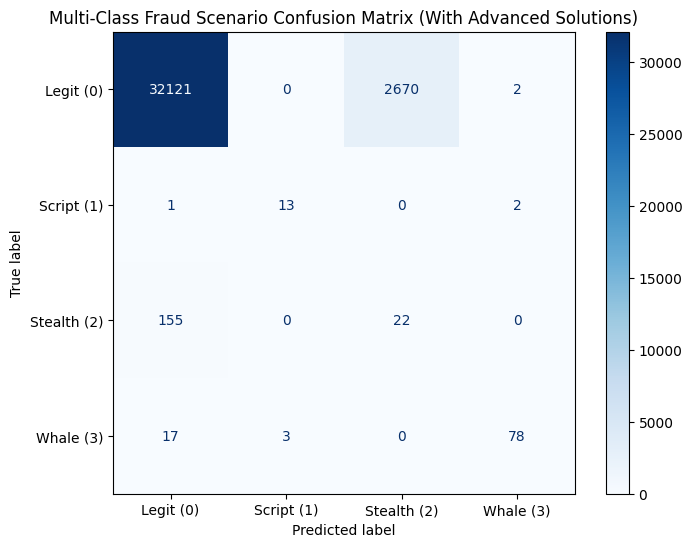

In [ ]:
y_pred = clf.predict(X_test)

print("Classification Report per Class/Scenario:")
print(classification_report(y_test, y_pred, target_names=[
    'Class 0 (Legitimate Baseline)',
    'Class 1 (Fixed-Threshold Script)',
    'Class 2 (Stealth Merchant)',
    'Class 3 (Whale Identity-Theft)'
], digits=4))

# Display the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    'Legit (0)', 'Script (1)', 'Stealth (2)', 'Whale (3)'
])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Multi-Class Fraud Scenario Confusion Matrix (With Advanced Solutions)")
plt.show()

### Cell 10: Comparative Feature Importances
This plots the feature importances to see which group of features (Rolling Counts, Graph topology, or Time-deltas) contributed the most to separating the fraud scenarios.

/tmp/ipykernel_14328/52414153.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


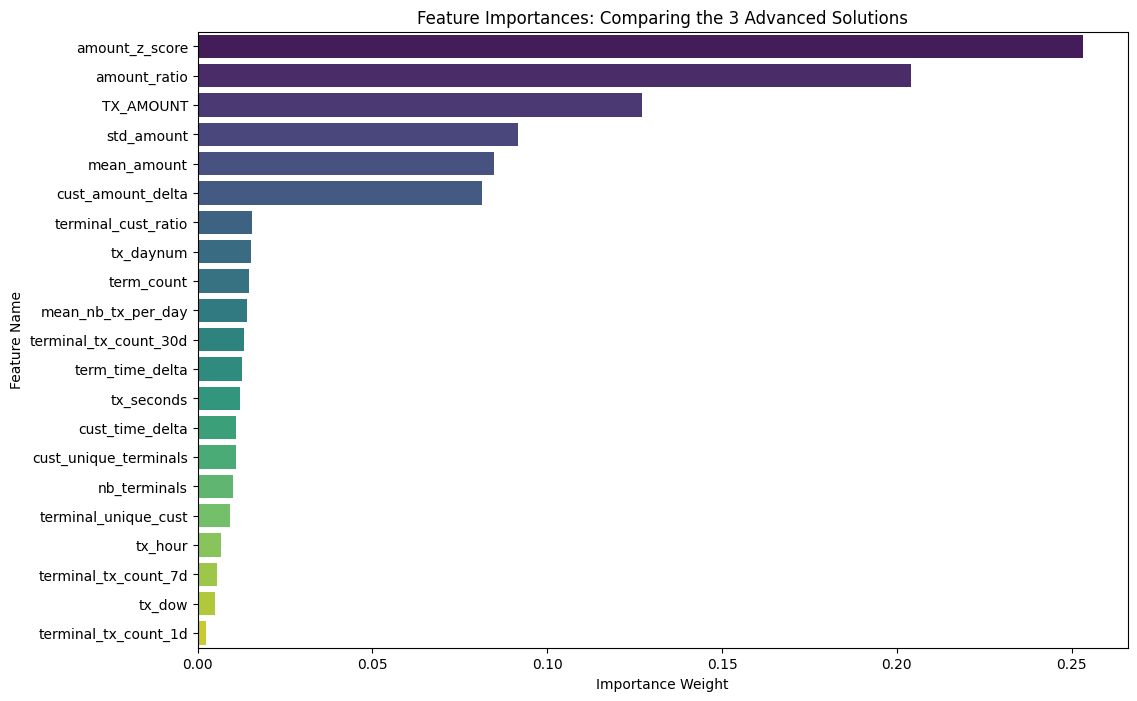

,Feature,Importance
10,amount_z_score,0.253350
9,amount_ratio,0.203937
0,TX_AMOUNT,0.126995
6,std_amount,0.091660
5,mean_amount,0.084757
20,cust_amount_delta,0.081198
16,terminal_cust_ratio,0.015537
4,tx_daynum,0.015266
14,term_count,0.014694
7,mean_nb_tx_per_day,0.014057


In [ ]:
rf_model = clf.named_steps['rf']
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importances: Comparing the 3 Advanced Solutions")
plt.xlabel("Importance Weight")
plt.ylabel("Feature Name")
plt.show()

importance_df